<a href="https://colab.research.google.com/github/harshs-data/Deep-Learning/blob/main/perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

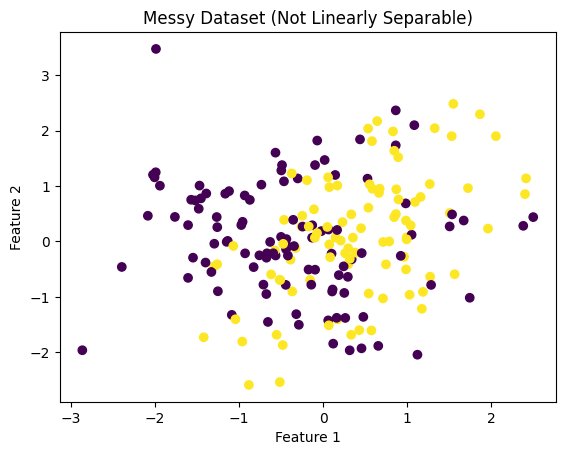

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate messy dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=0.5,      # LOW separation → messy
    flip_y=0.1,         # add label noise
    random_state=42
)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Messy Dataset (Not Linearly Separable)")
plt.show()

In [15]:
X.shape


(200, 2)

In [16]:
y.shape

(200,)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [21]:
p.fit(X_train, y_train)

Perceptron()

In [22]:
y_pred = p.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.68


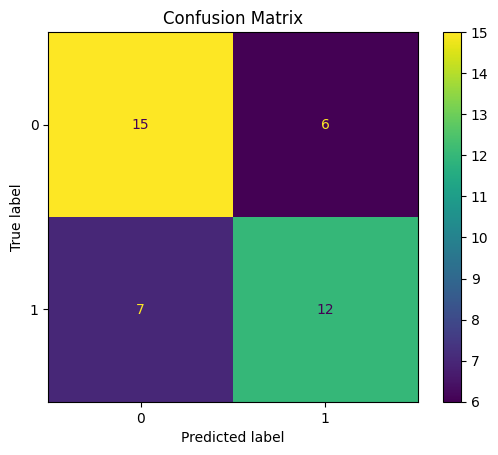

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(include_values=True)
plt.title("Confusion Matrix")
plt.show()

The confusion matrix above provides a detailed breakdown of correct and incorrect classifications. Now, let's also look at a classification report, which gives us precision, recall, and F1-score for each class.

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.71      0.70        21
           1       0.67      0.63      0.65        19

    accuracy                           0.68        40
   macro avg       0.67      0.67      0.67        40
weighted avg       0.67      0.68      0.67        40



<Axes: >

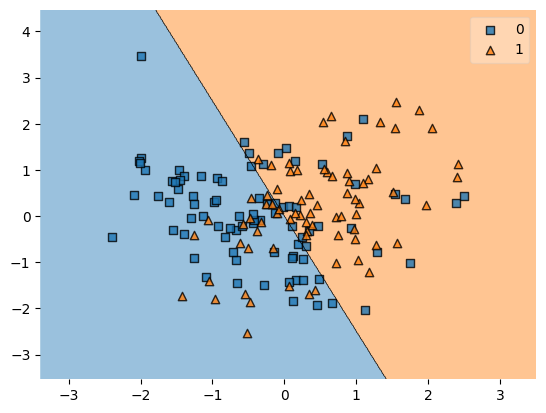

In [29]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train, clf=p)